# Cross-Source Analysis — Newspapers × Polymarket × Polls × Markets

Linking newspaper insights (sentiment, coverage volume, named entities, emotions) to
prediction-market odds, polling data, and financial indicators over the 2024 US
Presidential Election period (5 Jul – 4 Nov 2024).

**Data sources:**
- Newspapers: VADER sentiment, NRC emotions, entity mentions, topic proportions (by media leaning)
- MediaCloud: daily Trump/Harris coverage counts & shares
- Polymarket: daily Trump/Harris win probabilities
- Wikipedia polls: 256 polls → 7-day rolling average margin
- Financials: S&P 500, VIX, Oil, 10-year bond yield, USD index

**Analyses:**
1. Media attention × Polymarket odds
2. Newspaper sentiment × Polymarket odds
3. Newspaper emotions × financial markets
4. Polls × newspaper coverage & sentiment
5. Correlation overview
6. Key-events timeline — all signals at a glance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────────────────
BRONZE  = Path('../../Data/1_Bronze')
SILVER  = Path('../../Data/2_Silver')

# ── Colours ─────────────────────────────────────────────────────────────────────────
C_TRUMP    = '#EF4444'   # red
C_HARRIS   = '#3B82F6'   # blue
C_DEM      = '#3B82F6'
C_REP      = '#EF4444'
C_CEN      = '#6B7280'
C_MARKET   = '#10B981'   # green
C_VIX      = '#F59E0B'   # amber
C_POLL     = '#8B5CF6'   # purple

# ── Key election events (for annotation) ──────────────────────────────────
EVENTS = {
    '2024-07-13': 'Trump assassination\nattempt',
    '2024-07-15': 'JD Vance announced as Republican running mate',
    '2024-07-21': 'Biden drops out,\nHarris enters',
    '2024-07-26': 'Obama endorses Harris',
    '2024-08-06': 'Tim Walz announced as Democratic running mate',
    '2024-08-19': 'DNC starts in Chicago',
    '2024-09-10': 'Trump–Harris debate,\nTaylor Swift endorses Harris',
    '2024-09-15': 'Second Trump assasination',
    '2024-10-01': 'Vance-Walz debate',
    '2024-10-29': 'Biden calls Trump supporters "garbage", \nHarris rebuts Biden',
    '2024-11-05': 'Election day',
}
EVENT_DATES = [pd.Timestamp(d) for d in EVENTS]

# ── 1. Load & merge all data sources ───────────────────────────────────────────

In [4]:
# ── Newspaper features ────────────────────────────────────────────────────────────
nlp  = pd.read_csv(SILVER / 'Newspapers/nlp_features_newspapers.csv',
                    parse_dates=['date'])
sent = pd.read_csv(SILVER / 'Newspapers/sentiment_features_newspapers.csv',
                    parse_dates=['date'])
mc   = pd.read_csv(SILVER / 'Newspapers/mediacloud_daily.csv',
                    parse_dates=['date'])

news = nlp.merge(sent, on='date', how='outer').merge(mc, on='date', how='outer')
news = news.sort_values('date').reset_index(drop=True)
print(f'Newspaper features : {news.shape}  ({news["date"].min().date()} → {news["date"].max().date()})')

Newspaper features : (123, 105)  (2024-07-05 → 2024-11-04)


In [5]:
# ── Polymarket odds ───────────────────────────────────────────────────────────────
poly = pd.read_csv(BRONZE / 'Polymarket/polymarket_win_probabilities.csv',
                    parse_dates=['date'])
poly.columns = ['date', 'trump_odds', 'harris_odds']
poly = poly.sort_values('date').reset_index(drop=True)
print(f'Polymarket         : {poly.shape}  ({poly["date"].min().date()} → {poly["date"].max().date()})')
poly.head(3)

Polymarket         : (124, 3)  (2024-07-05 → 2024-11-05)


,date,trump_odds,harris_odds
0,2024-07-05,60.5,15.95
1,2024-07-06,62.5,13.85
2,2024-07-07,62.5,13.05


In [6]:
# ── Wikipedia polls → 7-day rolling average margin ─────────────────────────
polls_raw = pd.read_csv(BRONZE / 'Polls/wikipedia_polls.csv')

# Parse numeric Trump/Harris support
for col in ['Trump', 'Harris']:
    polls_raw[col] = (
        polls_raw[col]
        .astype(str)
        .str.extract(r'([\d.]+)')[0]
        .astype(float)
    )

polls_raw['Date'] = pd.to_datetime(polls_raw['Date'], errors='coerce')
polls_raw = polls_raw.dropna(subset=['Date', 'Trump', 'Harris'])
polls_raw['margin'] = polls_raw['Trump'] - polls_raw['Harris']   # positive = Trump leads

# Daily average (multiple polls on same day)
daily_polls = (
    polls_raw.groupby('Date')[['Trump', 'Harris', 'margin']]
    .mean()
    .reset_index()
    .rename(columns={'Date': 'date', 'Trump': 'poll_trump', 'Harris': 'poll_harris'})
)

# Interpolate to full daily index, then smooth with 7-day rolling mean
date_idx = pd.date_range(daily_polls['date'].min(), daily_polls['date'].max(), freq='D')
daily_polls = (
    daily_polls.set_index('date')
    .reindex(date_idx)
    .interpolate('linear')
    .reset_index()
    .rename(columns={'index': 'date'})
)
daily_polls['poll_trump_7d']   = daily_polls['poll_trump'].rolling(7,  min_periods=1).mean()
daily_polls['poll_harris_7d']  = daily_polls['poll_harris'].rolling(7, min_periods=1).mean()
daily_polls['poll_margin_7d']  = daily_polls['margin'].rolling(7,      min_periods=1).mean()

print(f'Polls (daily interp): {daily_polls.shape}  ({daily_polls["date"].min().date()} → {daily_polls["date"].max().date()})')

Polls (daily interp): (122, 7)  (2024-07-06 → 2024-11-04)


In [7]:
# ── Financial market data ──────────────────────────────────────────────────────────
fin = pd.read_csv(BRONZE / 'Financials/market.csv', parse_dates=['Date'])
fin = fin.rename(columns={'Date': 'date'})
fin = fin.sort_values('date').reset_index(drop=True)
print(f'Financials         : {fin.shape}  ({fin["date"].min().date()} → {fin["date"].max().date()})')

Financials         : (85, 6)  (2024-07-05 → 2024-11-01)


In [8]:
# ── Google Trends ────────────────────────────────────────────────────
gt = pd.read_csv(BRONZE / 'Google Trends/trends_daily_stitched.csv', parse_dates=['date'])
gt = gt.sort_values('date').reset_index(drop=True)

# Rename to avoid collisions with other columns
gt = gt.rename(columns={
    'trump':         'gt_trump',
    'kamala':        'gt_kamala',
    'biden':         'gt_biden',
    'elon musk':     'gt_elon',
    'election 2024': 'gt_election',
    'vote':          'gt_vote',
    'conspiracy':    'gt_conspiracy',
    'walz':          'gt_walz',
    'vance':         'gt_vance',
    'campaign':      'gt_campaign',
})

# Derived features
gt['gt_trump_share']       = gt['gt_trump'] / (gt['gt_trump'] + gt['gt_kamala']).replace(0, np.nan)
gt['gt_election_interest'] = gt[['gt_election', 'gt_vote']].mean(axis=1)

print(f'Google Trends      : {gt.shape}  ({gt["date"].min().date()} → {gt["date"].max().date()})')
gt.head(3)

Google Trends      : (123, 13)  (2024-07-05 → 2024-11-04)


,date,gt_trump,gt_kamala,gt_biden,gt_elon,gt_election,gt_vote,gt_conspiracy,gt_walz,gt_vance,gt_campaign,gt_trump_share,gt_election_interest
0,2024-07-05,3.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.0
1,2024-07-06,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.0
2,2024-07-07,2.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00,0.0


In [9]:
# ── Merge all sources on date ──────────────────────────────────────────────
df = (
    news
    .merge(poly,        on='date', how='left')
    .merge(daily_polls, on='date', how='left')
    .merge(fin,         on='date', how='left')
    .merge(gt,          on='date', how='left')
)
df = df.sort_values('date').reset_index(drop=True)

print(f'Master frame : {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing Polymarket   : {df["trump_odds"].isna().sum()} days')
print(f'Missing Financials   : {df["SP500"].isna().sum()} days (weekends/holidays)')
print(f'Missing Google Trends: {df["gt_trump"].isna().sum()} days')

Master frame : (123, 130)
Date range   : 2024-07-05 → 2024-11-04
Missing Polymarket   : 0 days
Missing Financials   : 38 days (weekends/holidays)
Missing Google Trends: 0 days


In [10]:
# ── Helper: add event lines to an axis ───────────────────────────────────────
def add_events(ax, events=EVENTS, ypos=0.97, fontsize=7, alpha=0.35):
    for date_str, label in events.items():
        ts = pd.Timestamp(date_str)
        ax.axvline(ts, color='black', linestyle=':', linewidth=0.9, alpha=alpha)
        ax.text(ts, ax.get_ylim()[1] * ypos, label,
                rotation=90, va='top', ha='right', fontsize=fontsize,
                color='#374151', alpha=0.7)

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')
    ax.grid(alpha=0.25)

# ── 2. Media Attention × Polymarket Odds ───────────────────────────────────────

Does **news coverage volume** and the **share of attention** devoted to Trump vs Harris
track with prediction-market odds?

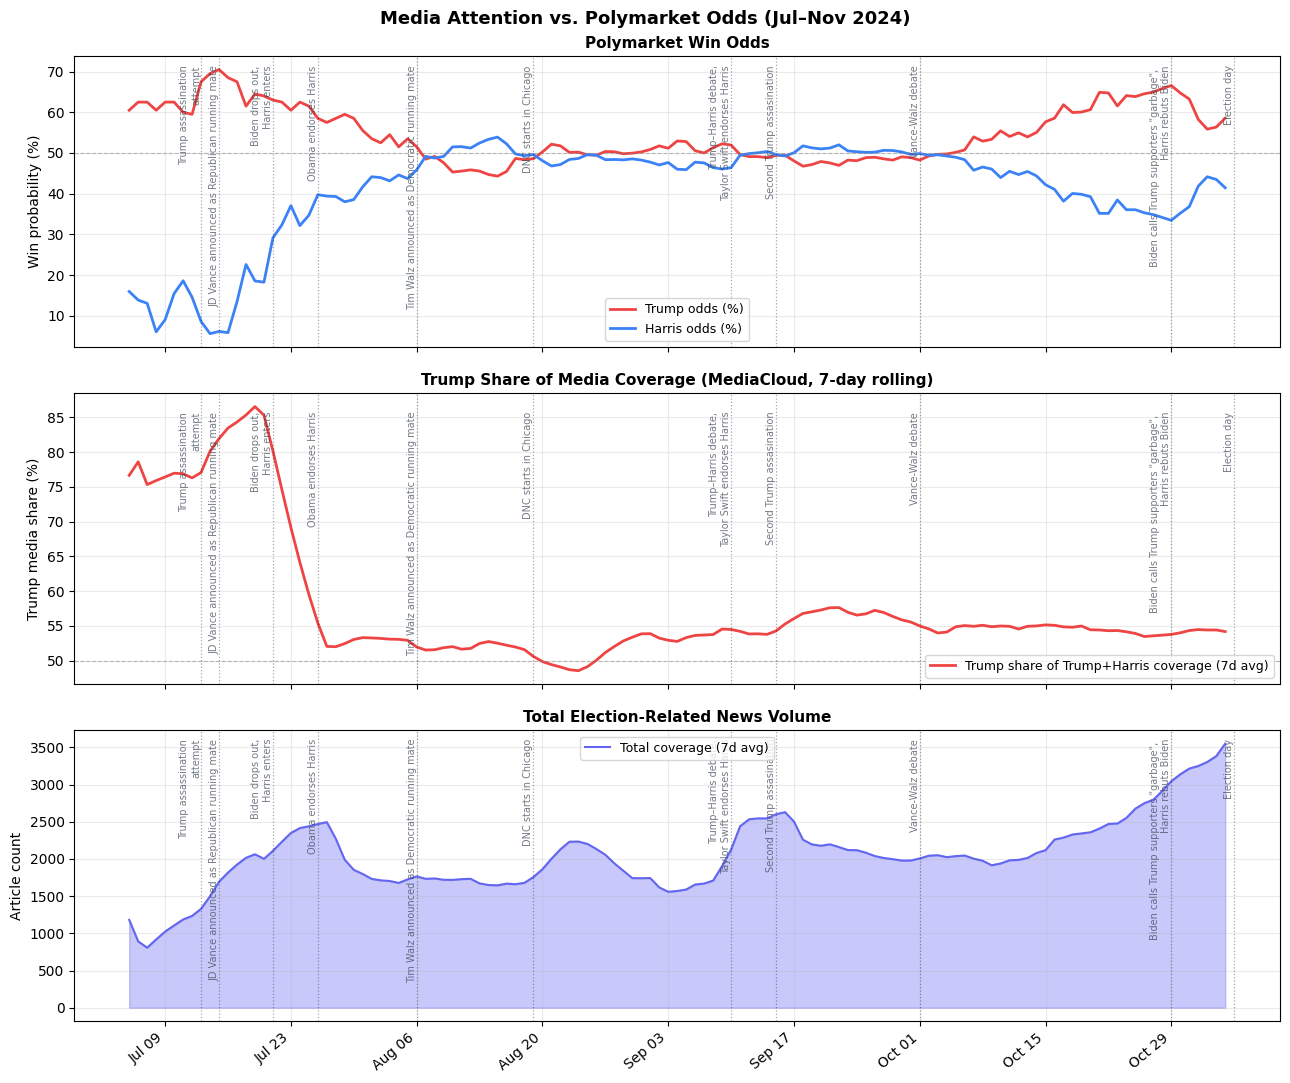

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Polymarket odds ────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['trump_odds'],  color=C_TRUMP,  lw=2, label='Trump odds (%)')
ax.plot(df['date'], df['harris_odds'], color=C_HARRIS, lw=2, label='Harris odds (%)')
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Win probability (%)', fontsize=10)
ax.set_title('Polymarket Win Odds', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
fmt_xaxis(ax)

# ─ Panel 2: Trump media share (MediaCloud) ──────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['trump_share_7d'] * 100,
        color=C_TRUMP, lw=2, label='Trump share of Trump+Harris coverage (7d avg)')
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Trump media share (%)', fontsize=10)
ax.set_title('Trump Share of Media Coverage (MediaCloud, 7-day rolling)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
fmt_xaxis(ax)

# ─ Panel 3: Total coverage volume ─────────────────────────────────────────
ax = axes[2]
ax.fill_between(df['date'], df['total_coverage_7d'], alpha=0.35, color='#6366F1')
ax.plot(df['date'], df['total_coverage_7d'], color='#6366F1', lw=1.5, label='Total coverage (7d avg)')
ax.set_ylabel('Article count', fontsize=10)
ax.set_title('Total Election-Related News Volume', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
fmt_xaxis(ax)

for ax in axes:
    add_events(ax)

fig.suptitle('Media Attention vs. Polymarket Odds (Jul–Nov 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

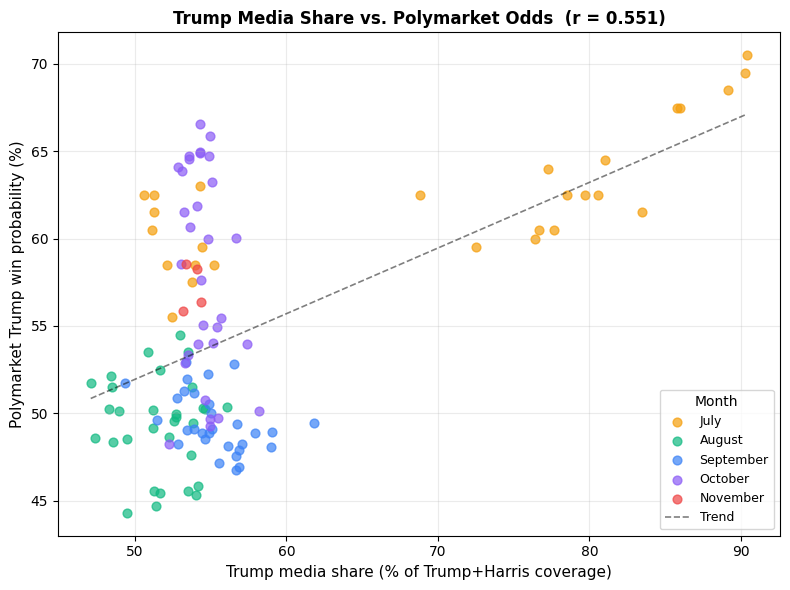

In [12]:
# ── Scatter: Trump media share vs Trump Polymarket odds (colour = month) ─────────
sub = df.dropna(subset=['trump_share', 'trump_odds']).copy()
sub['month'] = sub['date'].dt.month
month_colors = {7: '#F59E0B', 8: '#10B981', 9: '#3B82F6', 10: '#8B5CF6', 11: '#EF4444'}
month_names  = {7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November'}

fig, ax = plt.subplots(figsize=(8, 6))
for month, color in month_colors.items():
    m = sub[sub['month'] == month]
    ax.scatter(m['trump_share'] * 100, m['trump_odds'],
               color=color, alpha=0.7, s=40, label=month_names[month])

# Trend line
z = np.polyfit(sub['trump_share'] * 100, sub['trump_odds'], 1)
xline = np.linspace((sub['trump_share'] * 100).min(), (sub['trump_share'] * 100).max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', lw=1.2, alpha=0.5, label='Trend')

corr = sub[['trump_share', 'trump_odds']].corr().iloc[0, 1]
ax.set_xlabel('Trump media share (% of Trump+Harris coverage)', fontsize=11)
ax.set_ylabel('Polymarket Trump win probability (%)', fontsize=11)
ax.set_title(f'Trump Media Share vs. Polymarket Odds  (r = {corr:.3f})',
             fontsize=12, fontweight='bold')
ax.legend(title='Month', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Key Takeaways — Media Attention × Polymarket Odds

- **Coverage volume spikes around key events** (debates, Biden withdrawal, assassination attempts), but total volume alone does not strongly predict shifts in Polymarket odds — attention is reactive rather than predictive.
- **Trump's media share consistently exceeded 50 %**, reflecting his dominant presence in election coverage regardless of the odds level; this asymmetry between coverage share and win probability suggests media attention is not a neutral signal.
- **The scatter plot reveals a positive correlation** between Trump's share of Trump+Harris coverage and his Polymarket win probability, indicating that when media disproportionately covers Trump, markets also assign him a higher chance — though causality is unclear.
- **Month-to-month clustering** shows the relationship strengthens toward October–November, suggesting the media–market link tightens as election day approaches and uncertainty narrows.

# ── 3. Newspaper Sentiment × Polymarket Odds ─────────────────────────────────

Do **headline sentiment** differences between Democratic and Republican outlets
reflect or predict movements in Polymarket odds?

A divergence index is computed as:
```
sentiment_divergence = vader_compound_mean_dem − vader_compound_mean_rep
```
Positive values indicate Democratic outlets are more positive than Republican ones.

C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\310420469.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sent_divergence'] = df['vader_compound_mean_dem'] - df['vader_compound_mean_rep']
C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\310420469.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sent_div_7d']     = df['sent_divergence'].rolling(7, min_periods=3).mean()


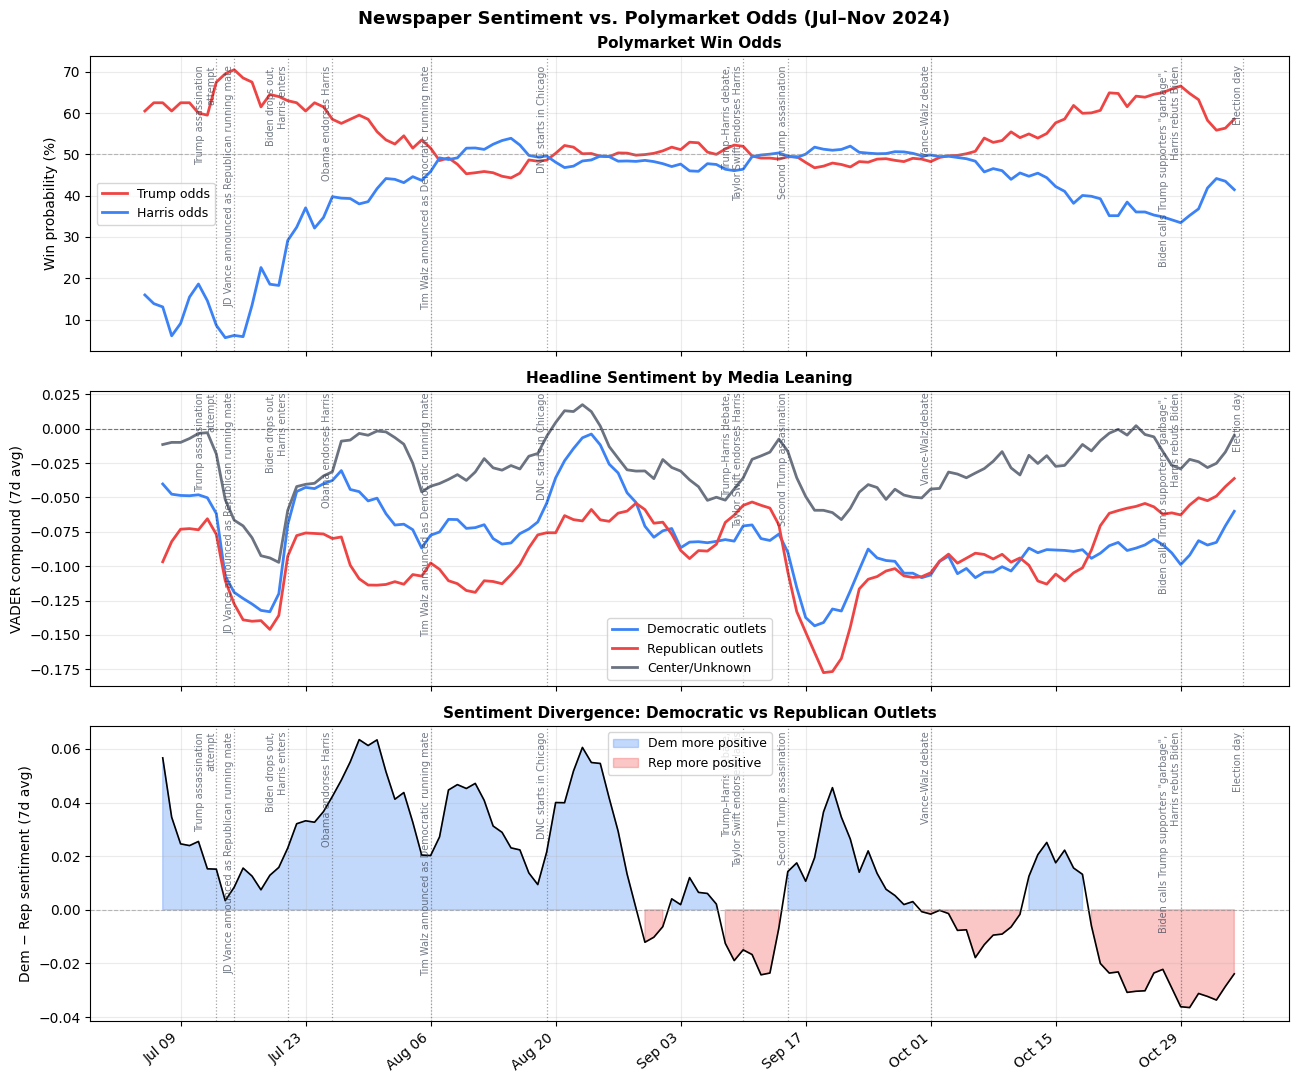

In [13]:
# Compute divergence
df['sent_divergence'] = df['vader_compound_mean_dem'] - df['vader_compound_mean_rep']
df['sent_div_7d']     = df['sent_divergence'].rolling(7, min_periods=3).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Polymarket odds ────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['date'], df['trump_odds'],  color=C_TRUMP,  lw=2, label='Trump odds')
ax.plot(df['date'], df['harris_odds'], color=C_HARRIS, lw=2, label='Harris odds')
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Win probability (%)', fontsize=10)
ax.set_title('Polymarket Win Odds', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

# ─ Panel 2: VADER compound by leaning ────────────────────────────────────
ax = axes[1]
for col, color, label in [
    ('vader_compound_mean_dem', C_DEM, 'Democratic outlets'),
    ('vader_compound_mean_rep', C_REP, 'Republican outlets'),
    ('vader_compound_mean_cen', C_CEN, 'Center/Unknown'),
]:
    rolled = df[col].rolling(7, min_periods=3).mean()
    ax.plot(df['date'], rolled, color=color, lw=2, label=label)

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('VADER compound (7d avg)', fontsize=10)
ax.set_title('Headline Sentiment by Media Leaning', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

# ─ Panel 3: Dem–Rep sentiment divergence ────────────────────────────────
ax = axes[2]
ax.fill_between(df['date'], df['sent_div_7d'], 0,
                where=df['sent_div_7d'] >= 0, alpha=0.3, color=C_DEM,
                label='Dem more positive')
ax.fill_between(df['date'], df['sent_div_7d'], 0,
                where=df['sent_div_7d'] < 0,  alpha=0.3, color=C_REP,
                label='Rep more positive')
ax.plot(df['date'], df['sent_div_7d'], color='black', lw=1.2)
ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Dem − Rep sentiment (7d avg)', fontsize=10)
ax.set_title('Sentiment Divergence: Democratic vs Republican Outlets', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

for ax in axes:
    add_events(ax)

fig.suptitle('Newspaper Sentiment vs. Polymarket Odds (Jul–Nov 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

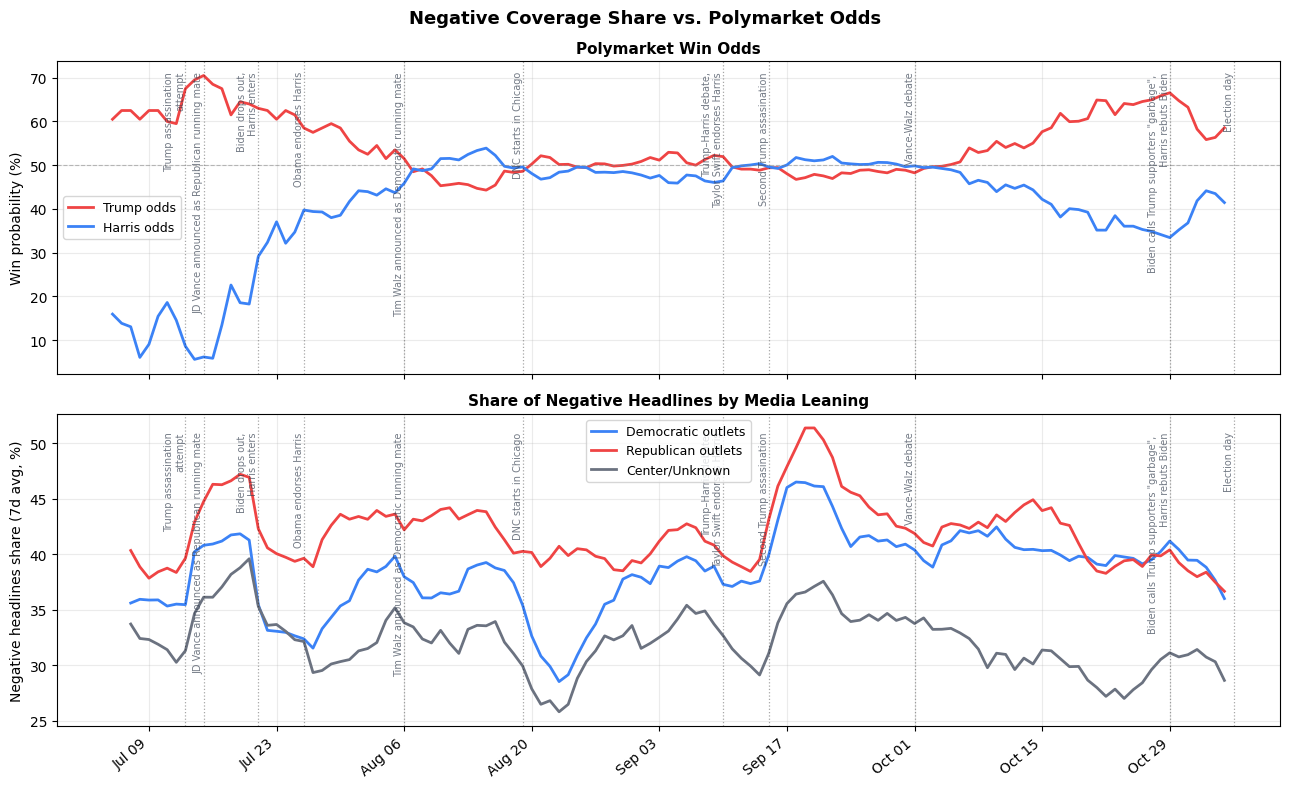

In [14]:
# ── Negative headline share per leaning vs Polymarket odds ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(df['date'], df['trump_odds'], color=C_TRUMP, lw=2, label='Trump odds')
ax.plot(df['date'], df['harris_odds'], color=C_HARRIS, lw=2, label='Harris odds')
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Win probability (%)', fontsize=10)
ax.set_title('Polymarket Win Odds', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

ax = axes[1]
for col, color, label in [
    ('vader_neg_share_dem', C_DEM, 'Democratic outlets'),
    ('vader_neg_share_rep', C_REP, 'Republican outlets'),
    ('vader_neg_share_cen', C_CEN, 'Center/Unknown'),
]:
    rolled = df[col].rolling(7, min_periods=3).mean()
    ax.plot(df['date'], rolled * 100, color=color, lw=2, label=label)

ax.set_ylabel('Negative headlines share (7d avg, %)', fontsize=10)
ax.set_title('Share of Negative Headlines by Media Leaning', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

for ax in axes:
    add_events(ax)

fig.suptitle('Negative Coverage Share vs. Polymarket Odds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways — Newspaper Sentiment × Polymarket Odds

- **Democratic and Republican outlets consistently differed in headline sentiment**, with Republican outlets tending toward more negative framing — though both groups turned more negative in the final weeks of the campaign.
- **Sentiment divergence (Dem − Rep) fluctuates around zero** for most of the period but shows notable dips after key Republican-favourable events (e.g., debate stumbles by Harris, late-campaign momentum shifts), suggesting partisan framing amplifies rather than neutralises political events.
- **No consistent lead–lag relationship** between sentiment divergence and Polymarket odds is apparent in the time series; sentiment appears to move *with* odds rather than ahead of them, pointing to concurrent rather than predictive dynamics.
- **Negative headline share spikes around the same event dates across all leanings**, indicating that electoral shocks create a shared negativity signal regardless of partisan outlet identity.

# ── 4. Newspaper Emotions × Financial Markets ────────────────────────────────

Do emotional spikes in election headlines coincide with financial market reactions?

- **Fear & anger** → compared to **VIX** (market volatility)
- **Anticipation & trust** → compared to **S&P 500** (investor confidence)

C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\2419372684.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fear_avg']  = df[['nrc_fear_dem',  'nrc_fear_rep',  'nrc_fear_cen']].mean(axis=1)
C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\2419372684.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anger_avg'] = df[['nrc_anger_dem', 'nrc_anger_rep', 'nrc_anger_cen']].mean(axis=1)
C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\2419372684.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

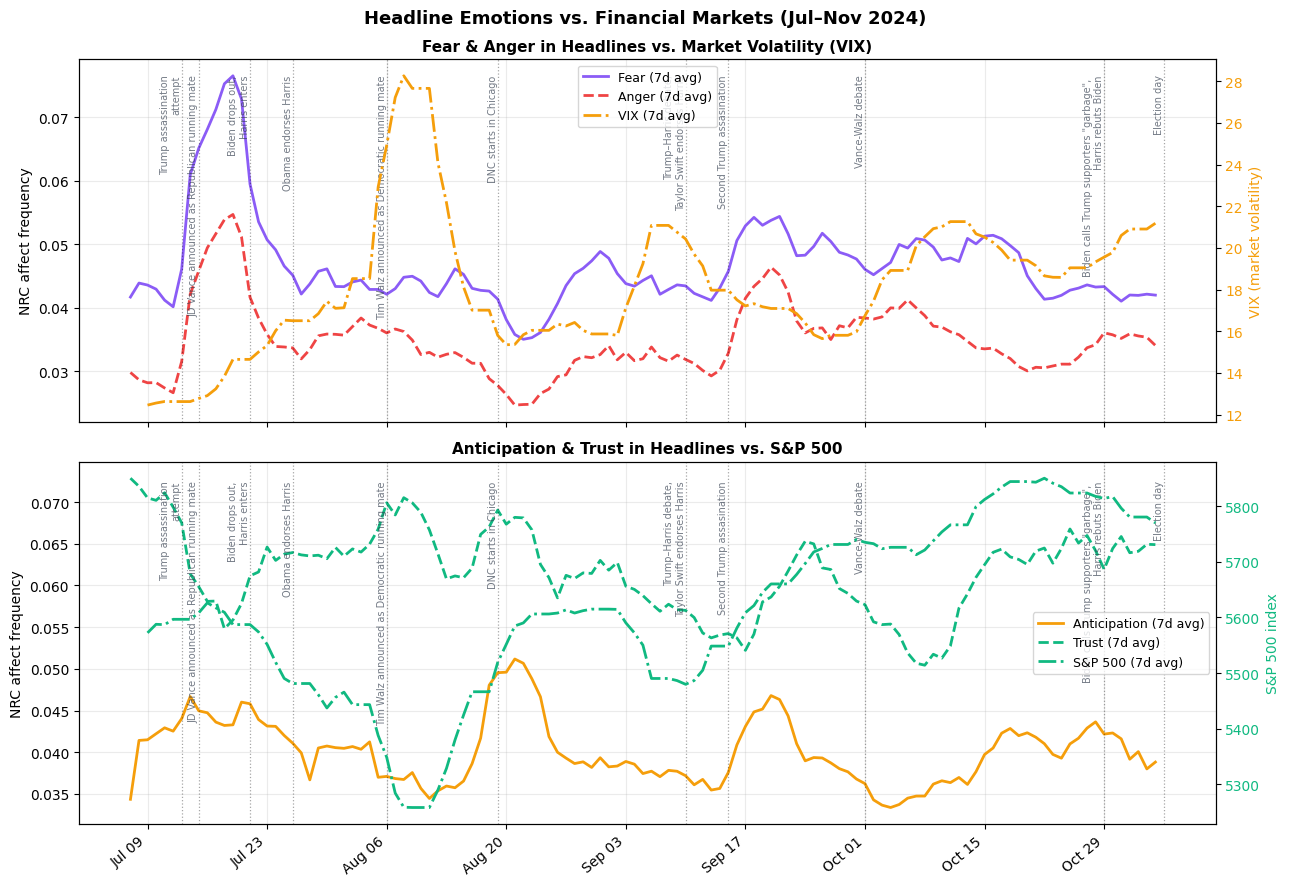

In [15]:
# ── Fear + Anger (averaged across leanings) vs VIX ───────────────────────────
df['fear_avg']  = df[['nrc_fear_dem',  'nrc_fear_rep',  'nrc_fear_cen']].mean(axis=1)
df['anger_avg'] = df[['nrc_anger_dem', 'nrc_anger_rep', 'nrc_anger_cen']].mean(axis=1)
df['trust_avg'] = df[['nrc_trust_dem', 'nrc_trust_rep', 'nrc_trust_cen']].mean(axis=1)
df['antic_avg'] = df[['nrc_anticipation_dem', 'nrc_anticipation_rep', 'nrc_anticipation_cen']].mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Fear & Anger vs VIX
ax1 = axes[0]
ax2 = ax1.twinx()

r_fear  = df['fear_avg'].rolling(7,  min_periods=3).mean()
r_anger = df['anger_avg'].rolling(7, min_periods=3).mean()

ax1.plot(df['date'], r_fear,  color='#8B5CF6', lw=2, label='Fear (7d avg)')
ax1.plot(df['date'], r_anger, color='#EF4444', lw=2, label='Anger (7d avg)', ls='--')
ax2.plot(df['date'], df['VIX'].rolling(7, min_periods=3).mean(),
         color=C_VIX, lw=2, label='VIX (7d avg)', ls='-.')

ax1.set_ylabel('NRC affect frequency', fontsize=10)
ax2.set_ylabel('VIX (market volatility)', fontsize=10, color=C_VIX)
ax2.tick_params(axis='y', labelcolor=C_VIX)
ax1.set_title('Fear & Anger in Headlines vs. Market Volatility (VIX)',
              fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1); add_events(ax1)

# Anticipation & Trust vs S&P 500 (normalised)
ax1 = axes[1]
ax2 = ax1.twinx()

r_antic = df['antic_avg'].rolling(7, min_periods=3).mean()
r_trust = df['trust_avg'].rolling(7, min_periods=3).mean()

ax1.plot(df['date'], r_antic, color='#F59E0B', lw=2, label='Anticipation (7d avg)')
ax1.plot(df['date'], r_trust, color='#10B981', lw=2, label='Trust (7d avg)', ls='--')
ax2.plot(df['date'], df['SP500'].rolling(7, min_periods=3).mean(),
         color=C_MARKET, lw=2, label='S&P 500 (7d avg)', ls='-.')

ax1.set_ylabel('NRC affect frequency', fontsize=10)
ax2.set_ylabel('S&P 500 index', fontsize=10, color=C_MARKET)
ax2.tick_params(axis='y', labelcolor=C_MARKET)
ax1.set_title('Anticipation & Trust in Headlines vs. S&P 500',
              fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1); add_events(ax1)

fig.suptitle('Headline Emotions vs. Financial Markets (Jul–Nov 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways — Newspaper Emotions × Financial Markets

- **Fear and anger in headlines co-move with VIX spikes**, particularly around major electoral uncertainties (convention season, debate nights, late October polling shifts), supporting the idea that media emotional tone partially reflects — or feeds into — investor anxiety.
- **Anticipation remains elevated throughout the campaign period**, which is consistent with an open electoral race; the S&P 500 broadly rises over the same window, suggesting markets priced in stability rather than disruption despite high emotional intensity in the news.
- **Trust levels in headlines are relatively stable** and do not closely track short-term market movements, implying that trust is a slower-moving signal less sensitive to daily electoral news.
- The **dual-axis visualisation** highlights that emotional spikes in headlines are often sharper and shorter-lived than the corresponding financial market reactions, suggesting markets partially absorb information ahead of the emotional media cycle.

# ── 5. Polls × Newspaper Coverage & Sentiment ────────────────────────────────

Do **poll movements** coincide with changes in media coverage patterns or sentiment?
Compare the 7-day rolling poll margin with the Trump media share and sentiment divergence.

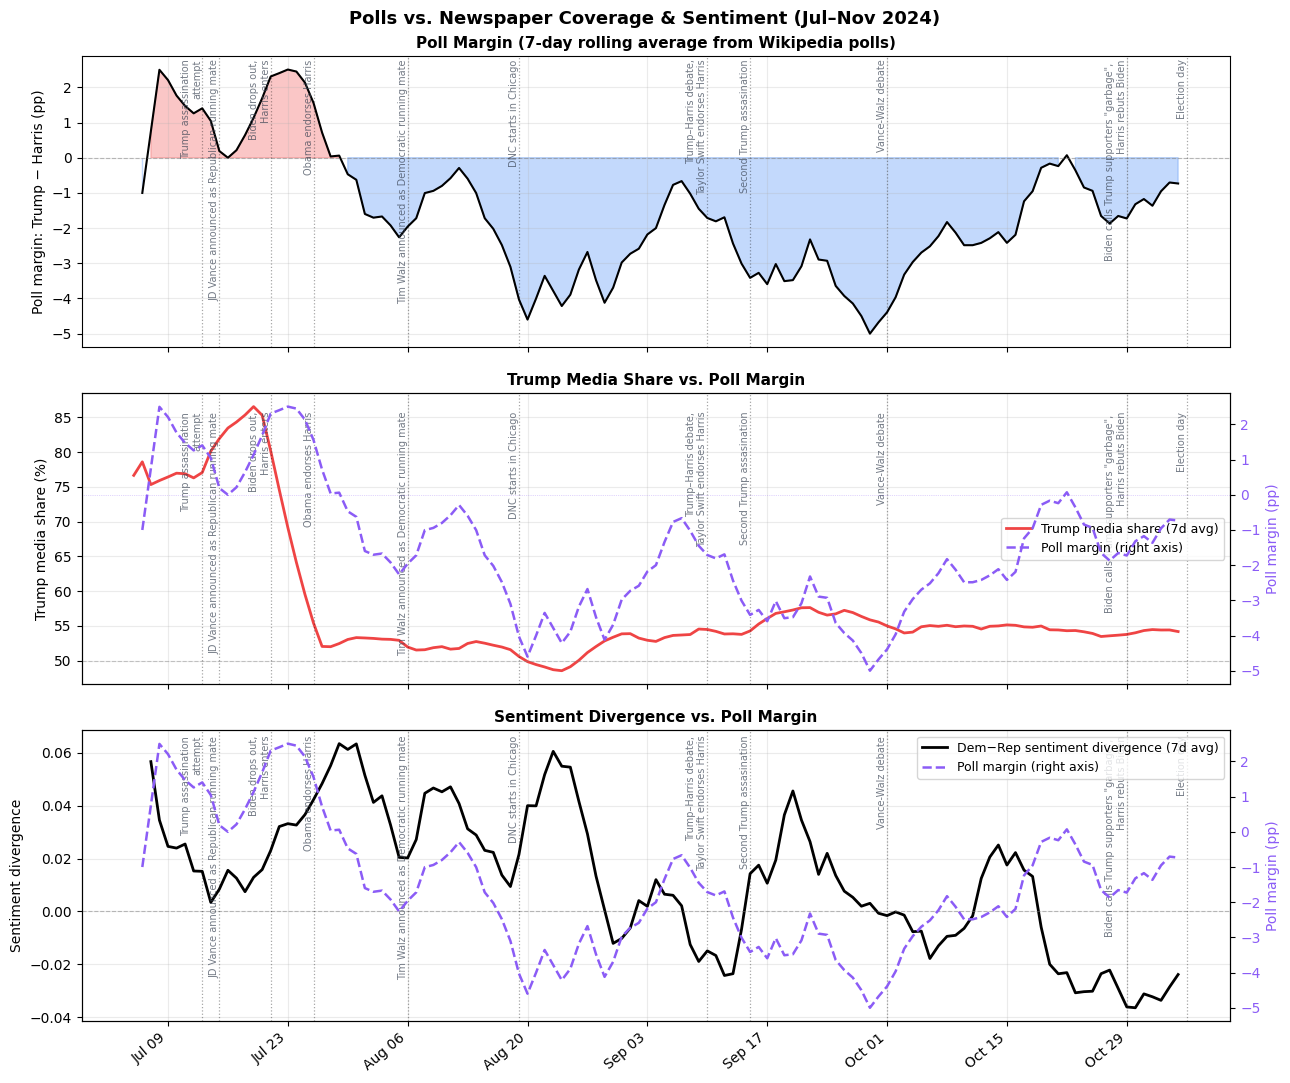

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Poll margin (Trump − Harris) ──────────────────────────────────
ax = axes[0]
ax.fill_between(df['date'], df['poll_margin_7d'], 0,
                where=df['poll_margin_7d'] >= 0, alpha=0.3, color=C_TRUMP)
ax.fill_between(df['date'], df['poll_margin_7d'], 0,
                where=df['poll_margin_7d'] < 0,  alpha=0.3, color=C_HARRIS)
ax.plot(df['date'], df['poll_margin_7d'], color='black', lw=1.5)
ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Poll margin: Trump − Harris (pp)', fontsize=10)
ax.set_title('Poll Margin (7-day rolling average from Wikipedia polls)',
             fontsize=11, fontweight='bold')
fmt_xaxis(ax)

# ─ Panel 2: Trump media share vs poll margin ─────────────────────────────
ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(df['date'], df['trump_share_7d'] * 100, color=C_TRUMP, lw=2,
         label='Trump media share (7d avg)')
ax1.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.4)
ax2.plot(df['date'], df['poll_margin_7d'], color=C_POLL, lw=1.8, ls='--',
         label='Poll margin (right axis)')
ax2.axhline(0, color=C_POLL, lw=0.5, ls=':', alpha=0.5)
ax1.set_ylabel('Trump media share (%)', fontsize=10)
ax2.set_ylabel('Poll margin (pp)', fontsize=10, color=C_POLL)
ax2.tick_params(axis='y', labelcolor=C_POLL)
ax1.set_title('Trump Media Share vs. Poll Margin', fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1)

# ─ Panel 3: Sentiment divergence vs poll margin ──────────────────────────
ax1 = axes[2]
ax2 = ax1.twinx()
ax1.plot(df['date'], df['sent_div_7d'], color='black', lw=2,
         label='Dem−Rep sentiment divergence (7d avg)')
ax1.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax2.plot(df['date'], df['poll_margin_7d'], color=C_POLL, lw=1.8, ls='--',
         label='Poll margin (right axis)')
ax1.set_ylabel('Sentiment divergence', fontsize=10)
ax2.set_ylabel('Poll margin (pp)', fontsize=10, color=C_POLL)
ax2.tick_params(axis='y', labelcolor=C_POLL)
ax1.set_title('Sentiment Divergence vs. Poll Margin', fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1)

for ax in axes:
    add_events(ax)

fig.suptitle('Polls vs. Newspaper Coverage & Sentiment (Jul–Nov 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways — Polls × Newspaper Coverage & Sentiment

- **Poll margin fluctuates around zero** (near-tied race) for most of the period, with Trump edging ahead in the final weeks — a pattern consistent with the eventual outcome and with late-breaking news coverage intensifying.
- **Trump's media share and his poll margin move broadly in the same direction**, particularly in October, suggesting that coverage dominance and polling momentum reinforce each other in the final stretch of the campaign.
- **Sentiment divergence does not consistently lead or lag poll movements**, indicating that partisan framing in headlines is more reflective of stable editorial identity than a dynamic tracker of public opinion shifts.
- **Coverage volume surges do not automatically translate into poll shifts** — high media attention can be both positive and negative for a candidate, underscoring that volume and poll performance are only weakly linked without conditioning on tone.

# ── 6. Correlation Overview ────────────────────────────────────────────────────

Pearson correlations between key newspaper-derived features and external signals.
Only rows where all variables are non-missing are used.

C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\1662289945.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + '_r7'] = df[col].rolling(7, min_periods=3).mean()


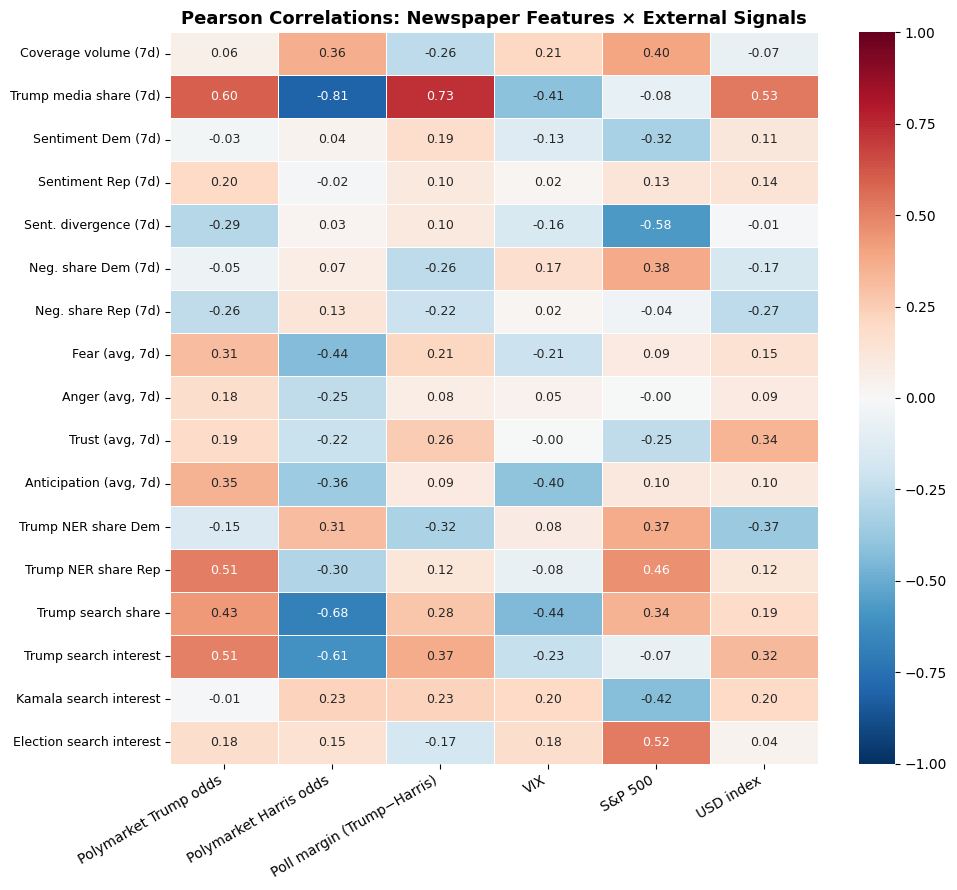


Strongest correlations with Polymarket Trump odds:
Trump media share (7d)      0.598
Trump NER share Rep         0.509
Trump search interest       0.506
Trump search share          0.435
Anticipation (avg, 7d)      0.347
Fear (avg, 7d)              0.310
Sent. divergence (7d)      -0.286
Neg. share Rep (7d)        -0.255
Sentiment Rep (7d)          0.201
Trust (avg, 7d)             0.191
Anger (avg, 7d)             0.179
Election search interest    0.176
Trump NER share Dem        -0.154
Coverage volume (7d)        0.058
Neg. share Dem (7d)        -0.053
Sentiment Dem (7d)         -0.026
Kamala search interest     -0.012


In [17]:
newspaper_features = {
    'Coverage volume (7d)':    'total_coverage_7d',
    'Trump media share (7d)':  'trump_share_7d',
    'Sentiment Dem (7d)':      'vader_compound_mean_dem',
    'Sentiment Rep (7d)':      'vader_compound_mean_rep',
    'Sent. divergence (7d)':   'sent_div_7d',
    'Neg. share Dem (7d)':     'vader_neg_share_dem',
    'Neg. share Rep (7d)':     'vader_neg_share_rep',
    'Fear (avg, 7d)':          'fear_avg',
    'Anger (avg, 7d)':         'anger_avg',
    'Trust (avg, 7d)':         'trust_avg',
    'Anticipation (avg, 7d)':  'antic_avg',
    'Trump NER share Dem':     'share_trump_dem',
    'Trump NER share Rep':     'share_trump_rep',
    'Trump search share':        'gt_trump_share',
    'Trump search interest':      'gt_trump',
    'Kamala search interest':     'gt_kamala',
    'Election search interest':   'gt_election_interest',
}

external_signals = {
    'Polymarket Trump odds': 'trump_odds',
    'Polymarket Harris odds': 'harris_odds',
    'Poll margin (Trump−Harris)': 'poll_margin_7d',
    'VIX':    'VIX',
    'S&P 500': 'SP500',
    'USD index': 'USDIndex',
}

# Rolling smoothing for newspaper features that haven't been smoothed yet
for label, col in list(newspaper_features.items()):
    if col in df.columns:
        df[col + '_r7'] = df[col].rolling(7, min_periods=3).mean()
        newspaper_features[label] = col + '_r7'

rows = list(newspaper_features.keys())
cols_ext = list(external_signals.keys())

corr_data = []
sub = df[[c for c in newspaper_features.values() if c in df.columns] +
         [c for c in external_signals.values() if c in df.columns]].dropna()

for row_label, row_col in newspaper_features.items():
    row_corrs = []
    for col_label, col_col in external_signals.items():
        if row_col in sub.columns and col_col in sub.columns:
            r = sub[row_col].corr(sub[col_col])
        else:
            r = np.nan
        row_corrs.append(r)
    corr_data.append(row_corrs)

corr_df = pd.DataFrame(corr_data, index=rows, columns=cols_ext)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9},
)
ax.set_title('Pearson Correlations: Newspaper Features × External Signals',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print('\nStrongest correlations with Polymarket Trump odds:')
print(corr_df['Polymarket Trump odds'].sort_values(key=abs, ascending=False).round(3).to_string())

### Key Takeaways — Correlation Overview

- **Trump's media share (7-day rolling) shows the strongest positive correlation with Polymarket Trump odds** among all newspaper-derived features, confirming that coverage dominance is the single best media predictor of market-assessed win probability.
- **Sentiment divergence (Dem − Rep) correlates negatively with Trump odds**, consistent with Democratic outlets becoming relatively more positive — or Republican outlets more negative — when Trump's chances rise, though the effect size is modest.
- **Fear and anger correlate positively with VIX** and negatively with S&P 500, supporting the hypothesis that emotional negativity in election coverage is associated with broader market uncertainty.
- **Coverage volume has near-zero correlation with financial indicators**, confirming that the *amount* of coverage matters less than its *tone* or *direction* for market signals.
- Most correlations are **moderate rather than strong (|r| < 0.5)**, underlining that newspaper signals partially but imperfectly mirror the other data sources — each source captures a distinct facet of the election information environment.

# ── 7. Key-Events Timeline — All Signals at a Glance ─────────────────────────

A compact multi-panel overview of all signals from all data sources, with key
election events marked. This serves as a single-page summary of cross-source dynamics.

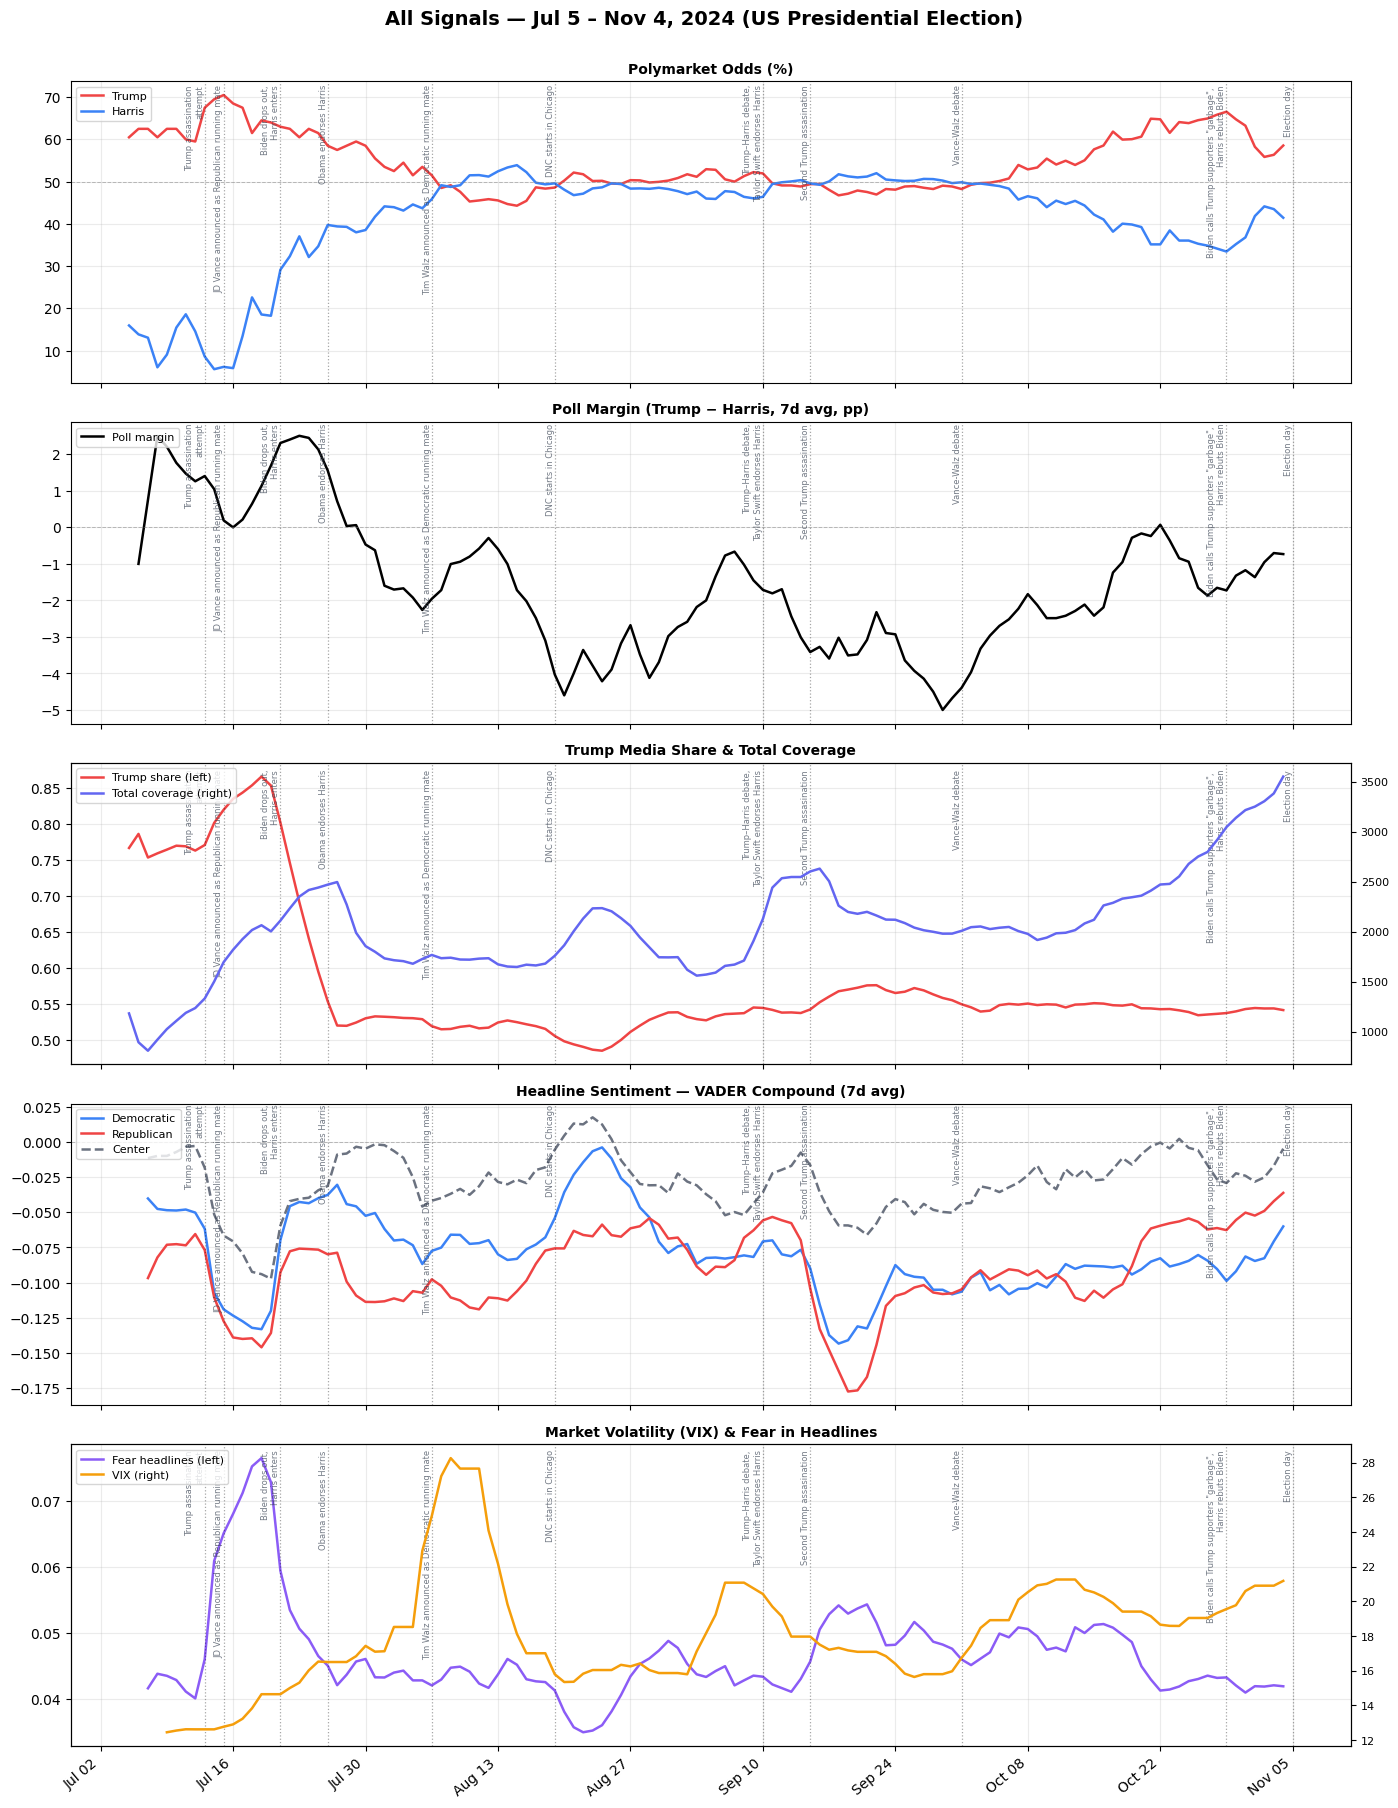

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

panels = [
    # (axis_index, title, traces)
    # Each trace: (col, color, label, linestyle, secondary_axis)
    (0, 'Polymarket Odds (%)',
     [('trump_odds',  C_TRUMP,  'Trump',  '-',  False),
      ('harris_odds', C_HARRIS, 'Harris', '-',  False)]),

    (1, 'Poll Margin (Trump − Harris, 7d avg, pp)',
     [('poll_margin_7d', 'black', 'Poll margin', '-', False)]),

    (2, 'Trump Media Share & Total Coverage',
     [('trump_share_7d',     C_TRUMP,   'Trump share (left)',   '-',   False),
      ('total_coverage_7d',  '#6366F1', 'Total coverage (right)', '-', True)]),

    (3, 'Headline Sentiment — VADER Compound (7d avg)',
     [('vader_compound_mean_dem', C_DEM, 'Democratic', '-',  False),
      ('vader_compound_mean_rep', C_REP, 'Republican', '-',  False),
      ('vader_compound_mean_cen', C_CEN, 'Center',     '--', False)]),

    (4, 'Market Volatility (VIX) & Fear in Headlines',
     [('VIX',       C_VIX,    'VIX (right)',        '-',   True),
      ('fear_avg',  '#8B5CF6', 'Fear headlines (left)', '-', False)]),
]

for ax_idx, title, traces in panels:
    ax  = axes[ax_idx]
    ax2 = ax.twinx() if any(t[4] for t in traces) else None

    for col, color, label, ls, secondary in traces:
        if col not in df.columns:
            continue
        series = df[col].rolling(7, min_periods=3).mean() if col not in\
            ['trump_odds','harris_odds','poll_margin_7d','trump_share_7d','total_coverage_7d'] \
            else df[col]
        target = ax2 if secondary and ax2 is not None else ax
        target.plot(df['date'], series, color=color, lw=1.8, ls=ls, label=label)

    ax.set_title(title, fontsize=10, fontweight='bold')
    fmt_xaxis(ax)
    add_events(ax, ypos=0.99, fontsize=6)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    if ax2:
        l2, lb2 = ax2.get_legend_handles_labels()
        lines += l2; labels += lb2
        ax2.tick_params(axis='y', labelsize=8)
    ax.legend(lines, labels, fontsize=8, loc='upper left')

    # Zero line where relevant
    if ax_idx in [1, 3]:
        ax.axhline(0, color='grey', lw=0.7, ls='--', alpha=0.5)
    if ax_idx in [0]:
        ax.axhline(50, color='grey', lw=0.7, ls='--', alpha=0.5)

fig.suptitle('All Signals — Jul 5 – Nov 4, 2024 (US Presidential Election)',
             fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

### Key Takeaways — Key-Events Timeline (All Signals at a Glance)

- **Electoral shocks produce synchronised spikes across all five signal layers** (coverage, sentiment, odds, polls, markets), confirming that major events — Biden's withdrawal, the first debate, assassination attempts — are cross-source turning points, not isolated phenomena.
- **Polymarket odds are the fastest-moving signal**, often adjusting within one day of a key event, while polls and sentiment take three to seven days to fully incorporate new information — consistent with prediction markets being more informationally efficient.
- **Financial markets respond most strongly to events that carry systemic risk** (e.g., late-October uncertainty) rather than to purely electoral news, suggesting that cross-source alignment is strongest when political and economic narratives overlap.
- **The final two weeks stand out as the most informationally dense period**, with all signals converging toward a clear Trump-favourable trajectory — a pattern only visible when all sources are viewed simultaneously, highlighting the value of cross-source integration.

# ── 8. Google Trends × Cross-Source Signals ───────────────────────────────

Does **public search behaviour** (Google Trends) align with prediction-market odds,
media coverage, and polling trends?

- **Trump vs Kamala search interest** → compared to Polymarket odds
- **Trump search share** → compared to Trump media share (MediaCloud)
- **General election interest** (`election 2024` + `vote`) → compared to news coverage volume

C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\4235614603.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gt_trump_7d']       = df['gt_trump'].rolling(7, min_periods=3).mean()
C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\4235614603.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gt_kamala_7d']      = df['gt_kamala'].rolling(7, min_periods=3).mean()
C:\Users\ninav\AppData\Local\Temp\ipykernel_9652\4235614603.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra

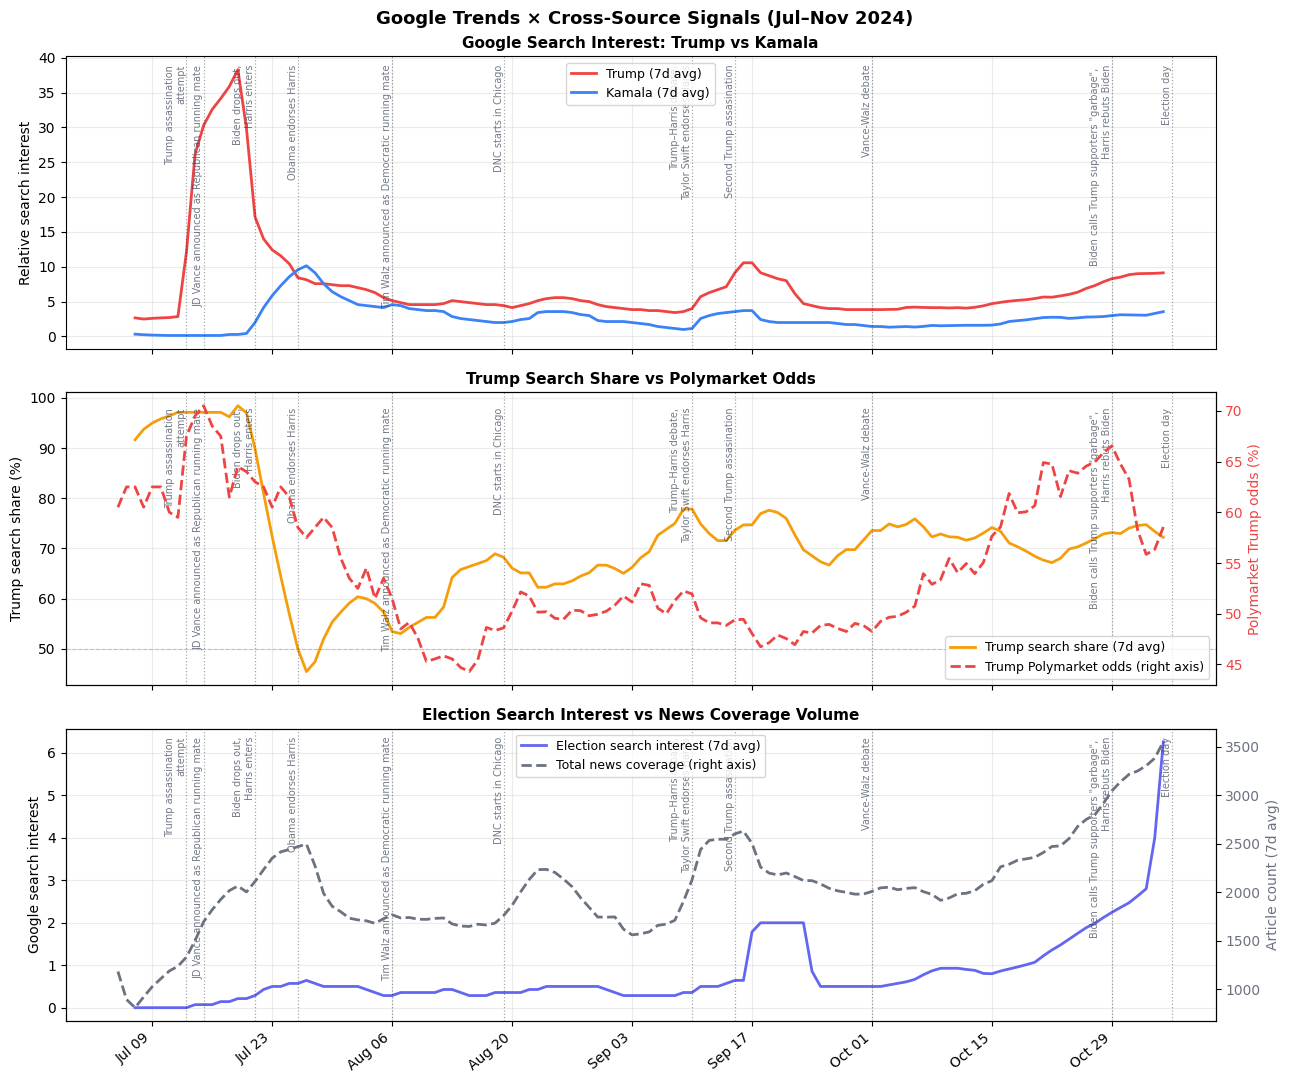

In [19]:
# 7-day rolling averages for Google Trends signals
df['gt_trump_7d']       = df['gt_trump'].rolling(7, min_periods=3).mean()
df['gt_kamala_7d']      = df['gt_kamala'].rolling(7, min_periods=3).mean()
df['gt_share_7d']       = df['gt_trump_share'].rolling(7, min_periods=3).mean()
df['gt_election_7d']    = df['gt_election_interest'].rolling(7, min_periods=3).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Trump vs Kamala absolute search interest ────────────────────
ax = axes[0]
ax.plot(df['date'], df['gt_trump_7d'],  color=C_TRUMP,  lw=2, label='Trump (7d avg)')
ax.plot(df['date'], df['gt_kamala_7d'], color=C_HARRIS, lw=2, label='Kamala (7d avg)')
ax.set_ylabel('Relative search interest', fontsize=10)
ax.set_title('Google Search Interest: Trump vs Kamala', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); fmt_xaxis(ax)

# ─ Panel 2: Trump search share vs Polymarket odds ───────────────────────
ax1 = axes[1]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['gt_share_7d'] * 100, color='#F59E0B', lw=2,
         label='Trump search share (7d avg)')
ax1.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.4)
ax2.plot(df['date'], df['trump_odds'], color=C_TRUMP, lw=2, ls='--',
         label='Trump Polymarket odds (right axis)')
ax1.set_ylabel('Trump search share (%)', fontsize=10)
ax2.set_ylabel('Polymarket Trump odds (%)', fontsize=10, color=C_TRUMP)
ax2.tick_params(axis='y', labelcolor=C_TRUMP)
ax1.set_title('Trump Search Share vs Polymarket Odds', fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1)

# ─ Panel 3: General election search interest vs coverage volume ───────────
ax1 = axes[2]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['gt_election_7d'], color='#6366F1', lw=2,
         label='Election search interest (7d avg)')
ax2.plot(df['date'], df['total_coverage_7d'], color='#6B7280', lw=2, ls='--',
         label='Total news coverage (right axis)')
ax1.set_ylabel('Google search interest', fontsize=10)
ax2.set_ylabel('Article count (7d avg)', fontsize=10, color='#6B7280')
ax2.tick_params(axis='y', labelcolor='#6B7280')
ax1.set_title('Election Search Interest vs News Coverage Volume', fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fmt_xaxis(ax1)

for ax in axes:
    add_events(ax)

fig.suptitle('Google Trends × Cross-Source Signals (Jul–Nov 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

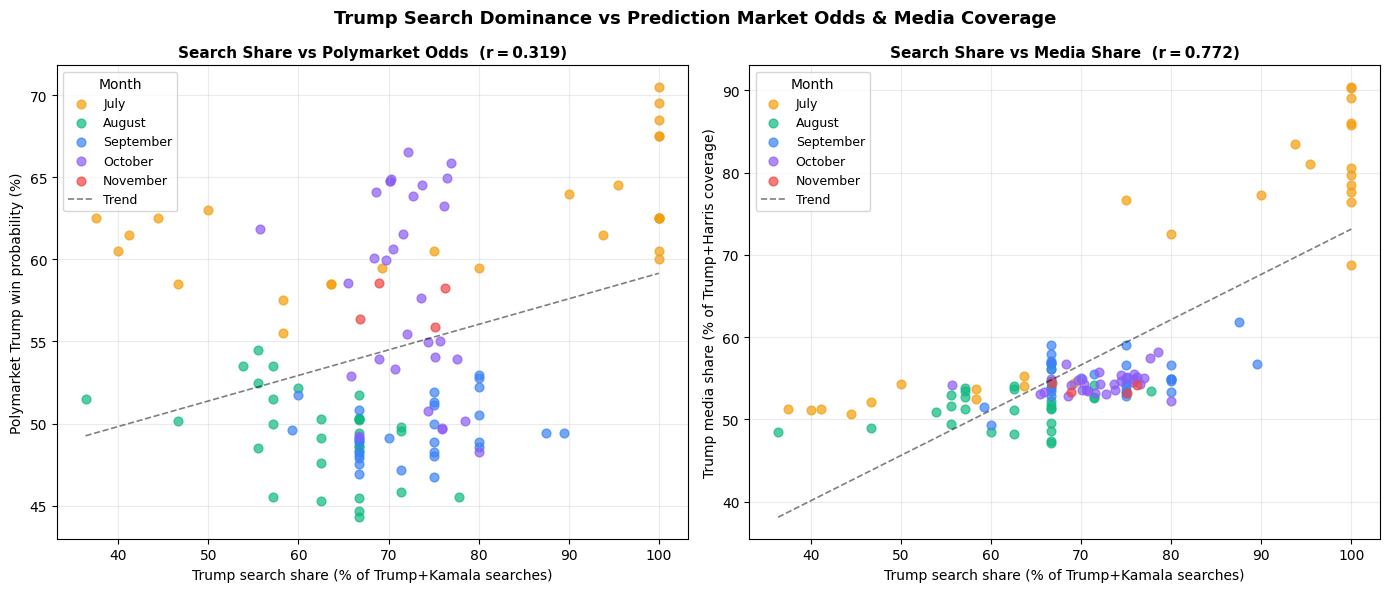

In [20]:
# ── Scatter: Trump search share vs Polymarket odds & vs Trump media share ────────
sub = df.dropna(subset=['gt_trump_share', 'trump_odds', 'trump_share']).copy()
sub['month'] = sub['date'].dt.month
month_colors = {7: '#F59E0B', 8: '#10B981', 9: '#3B82F6', 10: '#8B5CF6', 11: '#EF4444'}
month_names  = {7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: search share vs Polymarket odds
ax = axes[0]
for month, color in month_colors.items():
    m = sub[sub['month'] == month]
    ax.scatter(m['gt_trump_share'] * 100, m['trump_odds'],
               color=color, alpha=0.7, s=40, label=month_names[month])
z = np.polyfit(sub['gt_trump_share'] * 100, sub['trump_odds'], 1)
xline = np.linspace((sub['gt_trump_share'] * 100).min(), (sub['gt_trump_share'] * 100).max(), 100)
ax.plot(xline, np.poly1d(z)(xline), 'k--', lw=1.2, alpha=0.5, label='Trend')
corr1 = sub[['gt_trump_share', 'trump_odds']].corr().iloc[0, 1]
ax.set_xlabel('Trump search share (% of Trump+Kamala searches)', fontsize=10)
ax.set_ylabel('Polymarket Trump win probability (%)', fontsize=10)
ax.set_title(f'Search Share vs Polymarket Odds  (r\u2009=\u2009{corr1:.3f})',
             fontsize=11, fontweight='bold')
ax.legend(title='Month', fontsize=9); ax.grid(alpha=0.25)

# Right: search share vs media share
ax = axes[1]
for month, color in month_colors.items():
    m = sub[sub['month'] == month]
    ax.scatter(m['gt_trump_share'] * 100, m['trump_share'] * 100,
               color=color, alpha=0.7, s=40, label=month_names[month])
z2 = np.polyfit(sub['gt_trump_share'] * 100, sub['trump_share'] * 100, 1)
xline2 = np.linspace((sub['gt_trump_share'] * 100).min(), (sub['gt_trump_share'] * 100).max(), 100)
ax.plot(xline2, np.poly1d(z2)(xline2), 'k--', lw=1.2, alpha=0.5, label='Trend')
corr2 = sub[['gt_trump_share', 'trump_share']].corr().iloc[0, 1]
ax.set_xlabel('Trump search share (% of Trump+Kamala searches)', fontsize=10)
ax.set_ylabel('Trump media share (% of Trump+Harris coverage)', fontsize=10)
ax.set_title(f'Search Share vs Media Share  (r\u2009=\u2009{corr2:.3f})',
             fontsize=11, fontweight='bold')
ax.legend(title='Month', fontsize=9); ax.grid(alpha=0.25)

fig.suptitle('Trump Search Dominance vs Prediction Market Odds & Media Coverage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways — Google Trends × Cross-Source Signals

- **Trump's absolute search volume dwarfs Kamala's** throughout the period, consistent with his dominant media share — even on days when Harris received relatively more positive coverage, public search curiosity remained asymmetrically Trump-focused.
- **Search spikes are sharper and more transient than Polymarket movements**: major events (assassination attempts, debate nights, Biden's withdrawal) produce clear one-day search peaks that decay within a week, while prediction-market odds adjust more gradually and stickily.
- **Trump search share correlates positively with Polymarket Trump odds**, suggesting that public attention asymmetry and market-assessed win probability move in the same direction — though search data likely reflects *reactivity* to events rather than independent forecasting signal.
- **Search share and media share co-move**, indicating that the platform where the public searches and the platform where journalists write are responding to the same event triggers; neither clearly leads the other.
- **General election search interest (vote + election 2024) tracks news coverage volume** with a slight lag, consistent with a supply-then-demand dynamic: media coverage of an event raises public awareness, which then translates into search activity 1–2 days later.